<a href="https://colab.research.google.com/github/ascot119-rgb/Alex-s-Projects/blob/main/LinearRegression/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# No Normalization/Standardization

Iterations: 0
Parameters: 
1602.950482x1 + 8816.132339x2 + 3979.292890x3 + 5534.323624x4 + 2324.083486x5 + 2852.927064
Cost: 13014768135258.027344
Iterations: 100
Parameters: 
773.400178x1 + 80852.532949x2 + 45859.823743x3 + 70211.976426x4 + 19999.215595x5 + 21423.063392
Cost: 1425738497481.887207
Iterations: 200
Parameters: 
711.003918x1 + 144390.099810x2 + 84298.187761x3 + 127698.032517x4 + 37535.674161x5 + 38041.863902
Cost: 1267676450847.733887
Iterations: 300
Parameters: 
657.765198x1 + 197509.624140x2 + 118379.838350x3 + 177119.327940x4 + 54034.110101x5 + 51946.843780
Cost: 1151843525427.052979
Iterations: 400
Parameters: 
612.316790x1 + 241783.734209x2 + 148737.600133x3 + 219664.252302x4 + 69587.009797x5 + 63547.257313
Cost: 1066660002007.463013
Iterations: 500
Parameters: 
573.502716x1 + 278550.146089x2 + 175910.205775x3 + 256344.345482x4 + 84275.473391x5 + 73191.204949
Cost: 1003737357758.207397
Iterations: 600
Parameters: 
540.339150x1 + 308946.667281x2 + 200356.304601x3 + 28

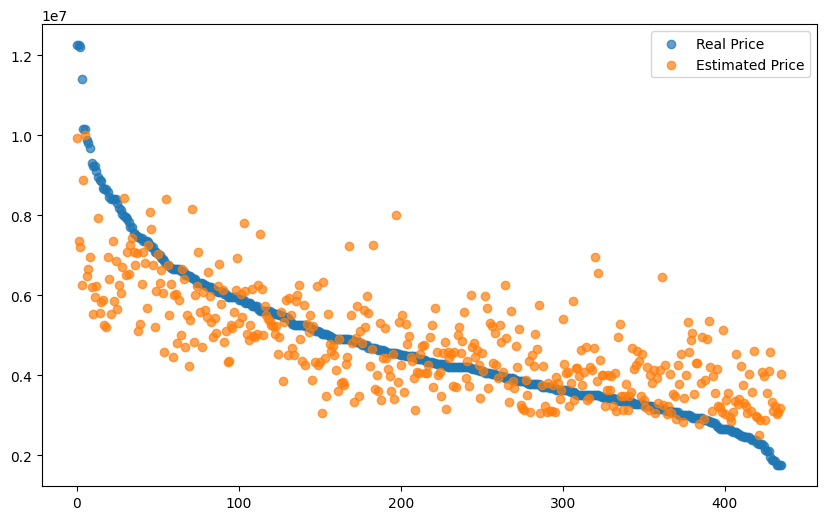

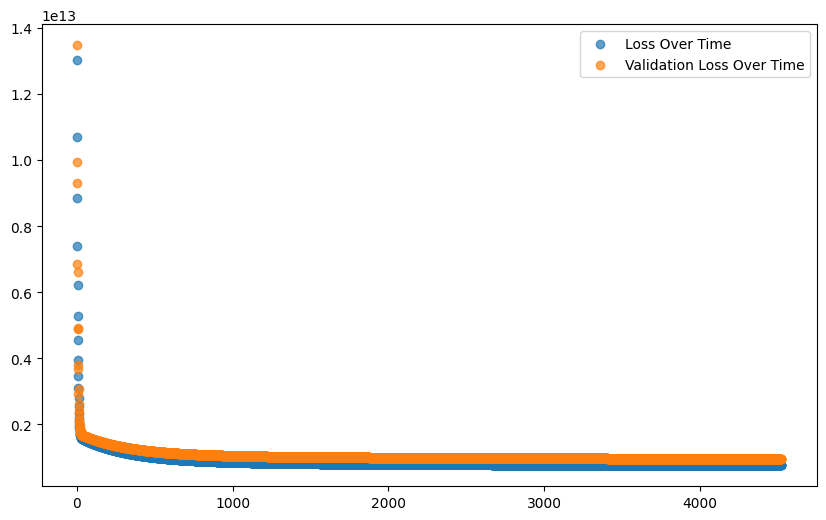

Iterations: 4527
Parameters: 
334.572276x1 + 338695.042312x2 + 582783.938759x3 + 532683.565610x4 + 342323.839965x5 + 88904.148586
Cost: 761920597632.823730
Final Validation Cost: 954249793390.874756


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import StandardScaler
def find(l, t):
  for i in range(len(l)):
    if l[i] == t:
      return i
  return -1
filepath = "/content/Housing.csv"

df = pd.read_csv(filepath)

chosenparams = ["area", "bedrooms", "bathrooms", "stories", "parking"]

y = df.values[:, 0].astype(np.float64)
paramnames = df.columns.values[:]
params = np.zeros(len(chosenparams) + 1, dtype=np.float64)
inputdata = []
for i in range(len(chosenparams)):
    column = find(paramnames, chosenparams[i])
    if df.values[1, column] == "yes" or df.values[1, column] == "no":
      inputdata.append(df.values[:, column].astype(int))
    else:
      for j in range(len(df.values[:, column])):
        df.values[:, column][j] = np.float64(df.values[:, column][j])
      inputdata.append(df.values[:, column])

inputdata = np.array(inputdata).astype(np.float64)

inputdata = inputdata.T
validation_indices = np.arange(0, len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)
inputdata = inputdata.T
validationdata = validationdata.T

index = np.arange(0, len(inputdata[0]))

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

m = len(y)



cf = 10
lr = 0.0006

def cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res))

def plot_result_to_target(result, y, x, loss, vloss):
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(y)), y, label='Real Price', alpha=0.7)
  plt.scatter(range(len(result)), result, label='Estimated Price', alpha=0.7)
  plt.legend() # Add this line to display labels
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(loss)), loss, label='Loss Over Time', alpha=0.7)
  plt.scatter(range(len(vloss)), vloss, label='Validation Loss Over Time', alpha=0.7)
  plt.legend() # Add this line to display labels
  #for i in range(len(x)):
    #plt.scatter(index, x[i], label=f'Index vs X{i+1}', alpha=0.7)
  plt.show()

def gradient(result, y, x):
  temp = np.zeros(len(params), dtype=np.float64)
  for ind in range(len(params) - 1):
    temp[ind] = np.float64(np.sum((result - y) * x[ind])) / m
  temp[len(params) - 1] = np.float64(np.sum(result - y)) / m
  temp[0] = temp[0] / 10000
  return temp

def linearfun(data, params):
  ans = np.zeros(len(data[0]), dtype=np.float64)
  for i in range(len(params) - 1):
    ans += list(params[i] * data[i])
  return ans + params[len(params) - 1]

def printdata(iter, cf, params):
  print(f"Iterations: {iter}")
  print(f"Parameters: ")
  for i in range (len(params) - 1):
    print(f"{params[i]:.6f}x{i+1} +", end = " ")
  print(f"{params[len(params) - 1]:.6f}")
  print(f"Cost: {cf:.6f}")


def linregression(data, params, y):
  # Early setup
  grad = [5000000] * len(params)
  iteration = 0
  loss_over_time = []
  validation_loss_over_time = []

  # Core Iteration
  while any(abs(x) > 100000 for x in grad):
    result = linearfun(data, params)
    cf = cost_function(result, y)
    grad = gradient(result, y, data)
    loss_over_time.append(cf)
    validation_cf = cost_function(linearfun(validationdata, params), validationy)
    validation_loss_over_time.append(validation_cf)
    for i in range(len(params)):
      params[i] = params[i] - lr * grad[i]
    if iteration % 100 == 0:
      printdata(iteration, cf, params)
    iteration += 1

  final_prediction = linearfun(data, params)
  #print(final_prediction)
  validationcf = cost_function(linearfun(validationdata, params), validationy)

  # Plotting and displaying information
  plot_result_to_target(final_prediction, y, data, loss_over_time, validation_loss_over_time)
  printdata(iteration, cf, params)
  print(f"Final Validation Cost: {validationcf:.6f}")
  iteration = 0



linregression(inputdata, params, y)

Iterations: 0
Parameters: 
160.295048x1 + 881.613234x2 + 397.929289x3 + 553.432362x4 + 253.948810x5 + 65.481468x6 + 110.987408x7 + 13.540183x8 + 110.703234x9 + 232.408349x10 + 84.256768x11 + 285.292706
Cost: 13014768135258.027344
Iterations: 100
Parameters: 
838.585140x1 + 12492.444457x2 + 6509.277877x3 + 9778.380947x4 + 3156.542349x5 + 1393.283143x6 + 2049.490450x7 + 343.017593x8 + 2517.381769x9 + 3066.852366x10 + 1244.991493x11 + 3553.953962
Cost: 1614446500480.435791
Iterations: 200
Parameters: 
830.311852x1 + 20535.177411x2 + 11054.101472x3 + 16829.960054x4 + 5027.615461x5 + 2480.965366x6 + 3564.365831x7 + 624.776982x8 + 4521.262891x9 + 4975.533859x10 + 2077.956634x11 + 5654.938771
Cost: 1588510602361.427734
Iterations: 300
Parameters: 
822.171028x1 + 28433.167675x2 + 15538.638950x3 + 23770.403427x4 + 6873.123475x5 + 3561.983569x6 + 5065.261156x7 + 904.635238x8 + 6509.761248x9 + 6871.117414x10 + 2908.095129x11 + 7717.969463
Cost: 1563384102649.838623
Iterations: 400
Parameters: 
81

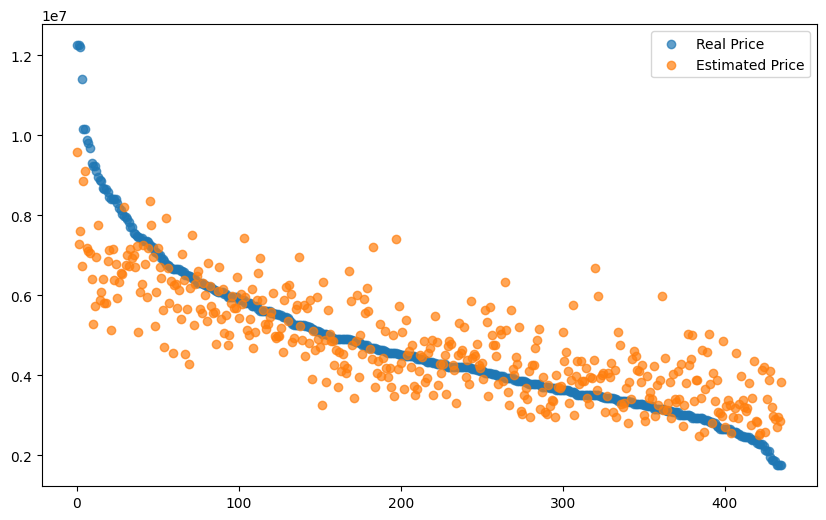

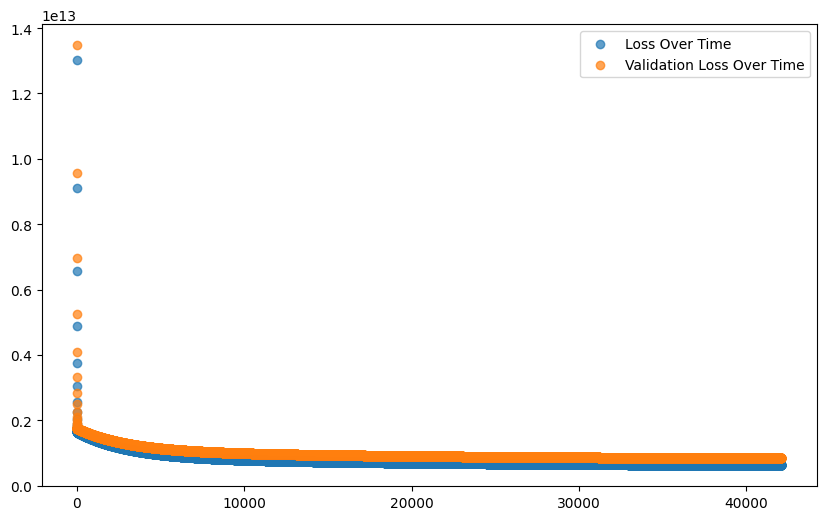

Iterations: 42110
Parameters: 
291.982901x1 + 303470.159046x2 + 527985.776338x3 + 494758.353601x4 + 202522.094059x5 + 248215.591190x6 + 266460.097221x7 + 75291.031214x8 + 411828.634874x9 + 321491.905507x10 + 234137.018007x11 + 73885.666177
Cost: 620229413027.050781
Final Validation Cost: 829305196848.166748


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import StandardScaler
def find(l, t):
  for i in range(len(l)):
    if l[i] == t:
      return i
  return -1
filepath = "/content/Housing.csv"

df = pd.read_csv(filepath)

chosenparams = ["area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "parking", "prefarea"]

y = df.values[:, 0].astype(np.float64)
paramnames = df.columns.values[:]
params = np.zeros(len(chosenparams) + 1, dtype=np.float64)
inputdata = []
for i in range(len(chosenparams)):
    column = find(paramnames, chosenparams[i])
    inputdata.append(df.values[:, column])


for i in range(len(inputdata)):
  for j in range(len(inputdata[i])):
    if inputdata[i][j] == "yes":
      inputdata[i][j] = 1
    elif inputdata[i][j] == "no":
      inputdata[i][j] = 0

inputdata = np.array(inputdata).astype(np.float64)

inputdata = inputdata.T
validation_indices = np.arange(0, len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)
inputdata = inputdata.T
validationdata = validationdata.T

index = np.arange(0, len(inputdata[0]))

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

m = len(y)



cf = 10
lr = 0.00006

def cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res))

def plot_result_to_target(result, y, x, loss, vloss):
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(y)), y, label='Real Price', alpha=0.7)
  plt.scatter(range(len(result)), result, label='Estimated Price', alpha=0.7)
  plt.legend() # Add this line to display labels
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(loss)), loss, label='Loss Over Time', alpha=0.7)
  plt.scatter(range(len(vloss)), vloss, label='Validation Loss Over Time', alpha=0.7)
  plt.legend() # Add this line to display labels
  #for i in range(len(x)):
    #plt.scatter(index, x[i], label=f'Index vs X{i+1}', alpha=0.7)
  plt.show()

def gradient(result, y, x):
  temp = np.zeros(len(params), dtype=np.float64)
  for ind in range(len(params) - 1):
    temp[ind] = np.float64(np.sum((result - y) * x[ind])) / m
  temp[len(params) - 1] = np.float64(np.sum(result - y)) / m
  temp[0] = temp[0] / 10000
  return temp

def linearfun(data, params):
  ans = np.zeros(len(data[0]), dtype=np.float64)
  for i in range(len(params) - 1):
    ans += list(params[i] * data[i])
  return ans + params[len(params) - 1]

def printdata(iter, cf, params):
  print(f"Iterations: {iter}")
  print(f"Parameters: ")
  for i in range (len(params) - 1):
    print(f"{params[i]:.6f}x{i+1} +", end = " ")
  print(f"{params[len(params) - 1]:.6f}")
  print(f"Cost: {cf:.6f}")


def linregression(data, params, y):
  # Early setup
  grad = [500000] * len(params)
  iteration = 0
  loss_over_time = []
  validation_loss_over_time = []

  # Core Iteration
  while any(abs(x) > 100000 for x in grad):
    result = linearfun(data, params)
    cf = cost_function(result, y)
    grad = gradient(result, y, data)
    loss_over_time.append(cf)
    validation_cf = cost_function(linearfun(validationdata, params), validationy)
    validation_loss_over_time.append(validation_cf)
    for i in range(len(params)):
      params[i] = params[i] - lr * grad[i]
    if iteration % 100 == 0:
      printdata(iteration, cf, params)
    iteration += 1

  final_prediction = linearfun(data, params)
  #print(final_prediction)
  validationcf = cost_function(linearfun(validationdata, params), validationy)

  # Plotting and displaying information
  plot_result_to_target(final_prediction, y, data, loss_over_time, validation_loss_over_time)
  printdata(iteration, cf, params)
  print(f"Final Validation Cost: {validationcf:.6f}")
  iteration = 0



linregression(inputdata, params, y)

# Data Standardization

Iterations: 0
Parameters: 
0.005370x1 + 0.003744x2 + 0.005247x3 + 0.004228x4 + 0.003809x5 + -0.000063
Cost: 0.489789
Iterations: 100
Parameters: 
0.275287x1 + 0.129789x2 + 0.240859x3 + 0.190637x4 + 0.167453x5 + -0.005528
Cost: 0.219534
Iterations: 200
Parameters: 
0.342704x1 + 0.115061x2 + 0.283052x3 + 0.224517x4 + 0.184224x5 + -0.007950
Cost: 0.210043
Iterations: 300
Parameters: 
0.365049x1 + 0.096380x2 + 0.294476x3 + 0.235904x4 + 0.181059x5 + -0.008663
Cost: 0.208847
Iterations: 400
Parameters: 
0.374126x1 + 0.084920x2 + 0.299206x3 + 0.241959x4 + 0.177079x5 + -0.008772
Cost: 0.208545
Iterations: 500
Parameters: 
0.378260x1 + 0.078506x2 + 0.301597x3 + 0.245558x4 + 0.174499x5 + -0.008719
Cost: 0.208458
Iterations: 600
Parameters: 
0.380258x1 + 0.074959x2 + 0.302875x3 + 0.247694x4 + 0.173041x5 + -0.008645
Cost: 0.208432


/tmp/ipykernel_1380/2207644.py:132: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  params[-1] = scaler_y.scale_ * params[-1] - scaler_y.scale_ * sum_term + scaler_y.mean_


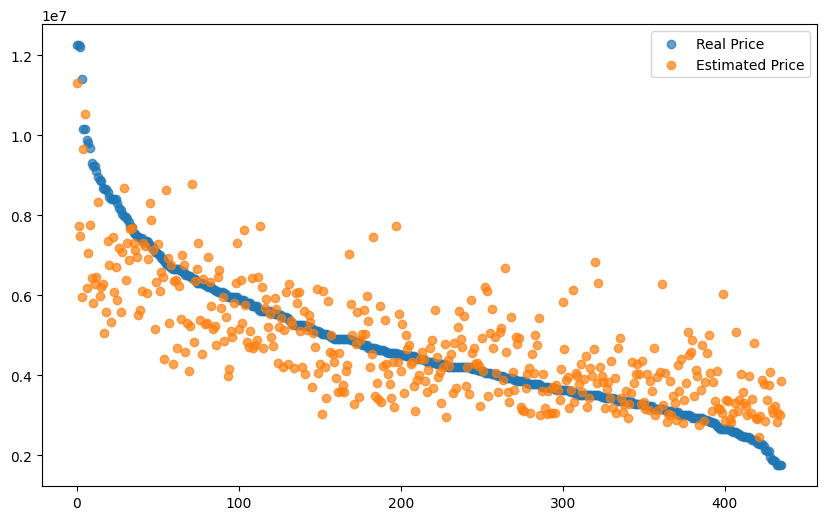

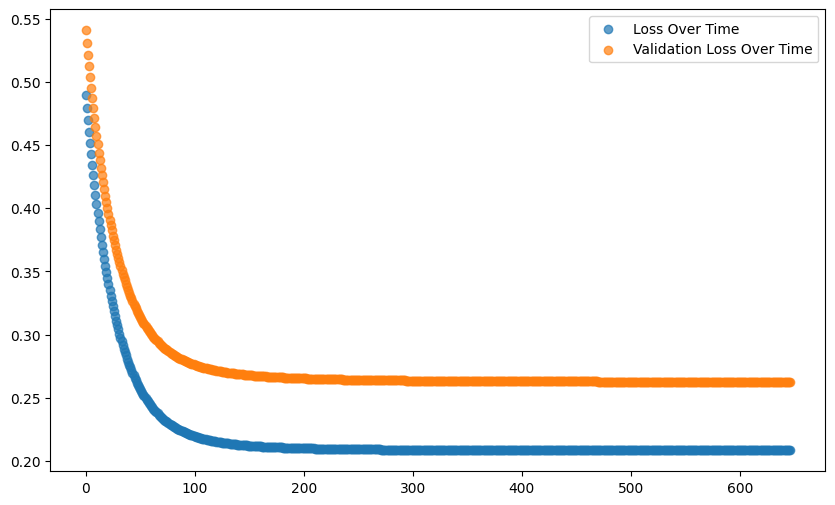

Iterations: 647
Parameters: 
328.212302x1 + 187307.997772x2 + 1128828.064406x3 + 535484.804258x4 + 374743.598268x5 + -173911.368627
Cost: 727854773455.831299
Final Validation Cost: 1228458921282.454346


In [ ]:
# Set 1 with
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import StandardScaler
def find(l, t):
  for i in range(len(l)):
    if l[i] == t:
      return i
  return -1
filepath = "/content/Housing.csv"

df = pd.read_csv(filepath)

chosenparams = ["area", "bedrooms", "bathrooms", "stories", "parking"]
scaler_X = StandardScaler() # Scaler for input features
scaler_y = StandardScaler() # Scaler for target variable

y = df.values[:, 0]
paramnames = df.columns.values[:]
params = np.zeros(len(chosenparams) + 1)
inputdata = []
for i in range(len(chosenparams)):
    column = find(paramnames, chosenparams[i])
    if df.values[1, column] == "yes" or df.values[1, column] == "no":
      inputdata.append(df.values[:, column].astype(int))
    else:
      for j in range(len(df.values[:, column])):
        df.values[:, column][j] = np.float64(df.values[:, column][j])
      inputdata.append(df.values[:, column])



inputdata = np.array(inputdata).T
originaldata = inputdata.copy()
originaldata = np.array(originaldata).T
inputdata = scaler_X.fit_transform(inputdata) # Fit and transform input features

validation_indices = np.arange(0, len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)

originaldata = originaldata.T
originaldata = np.delete(originaldata, validation_indices, axis=0)
originaldata = originaldata.T

inputdata = inputdata.T
validationdata = validationdata.T

index = np.arange(0, len(inputdata[0]))

y = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(-1) # Fit and transform target variable

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

m = len(y)



cf = 10
lr = 0.01

def cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res))

def plot_result_to_target(result, y, x, loss, vloss):
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(y)), y, label='Real Price', alpha=0.7)
  plt.scatter(range(len(result)), result, label='Estimated Price', alpha=0.7)
  plt.legend() # Add this line to display labels
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(loss)), loss, label='Loss Over Time', alpha=0.7)
  plt.scatter(range(len(vloss)), vloss, label='Validation Loss Over Time', alpha=0.7)
  plt.legend() # Add this line to display labels
  #for i in range(len(x)):
    #plt.scatter(index, x[i], label=f'Index vs X{i+1}', alpha=0.7)
  plt.show()

def gradient(result, y, x):
  temp = np.zeros(len(params))
  for ind in range(len(params) - 1):
    temp[ind] = np.float64(np.sum((result - y) * x[ind])) / m
  temp[len(params) - 1] = np.float64(np.sum(result - y)) / m
  return temp

def linearfun(data, params):
  ans = np.zeros(len(data[0]))
  for i in range(len(params) - 1):
    ans += list(params[i] * data[i])
  return ans + params[len(params) - 1]

def printdata(iter, cf, params):
  print(f"Iterations: {iter}")
  print(f"Parameters: ")
  for i in range (len(params) - 1):
    print(f"{params[i]:.6f}x{i+1} +", end = " ")
  print(f"{params[len(params) - 1]:.6f}")
  print(f"Cost: {cf:.6f}")


def linregression(data, params, y, origdata):
  # Early setup
  grad = [500] * len(params)
  iteration = 0
  loss_over_time = []
  validation_loss_over_time = []

  # Core Iteration
  while any(abs(x) > 0.002 for x in grad):
    result = linearfun(data, params)
    cf = cost_function(result, y)
    grad = gradient(result, y, data)
    loss_over_time.append(cf)
    validation_cf = cost_function(linearfun(validationdata, params), validationy)
    validation_loss_over_time.append(validation_cf)
    for i in range(len(params)):
      params[i] = params[i] - lr * grad[i]
    if iteration % 100 == 0:
      printdata(iteration, cf, params)
    iteration += 1

  # Calculating final data
  original_y_values = scaler_y.inverse_transform(y.reshape(-1, 1)).reshape(-1)
  params[:-1] = (scaler_y.scale_ * params[:-1]) / scaler_X.scale_
  sum_term = np.sum((params[:-1] * scaler_X.mean_) / scaler_y.scale_)
  params[-1] = scaler_y.scale_ * params[-1] - scaler_y.scale_ * sum_term + scaler_y.mean_
  final_prediction = linearfun(origdata, params)
  #print(final_prediction)
  y = original_y_values
  cf = cost_function(final_prediction, y)
  validationcf = cost_function(linearfun(validationdata, params), validationy)

  # Plotting and displaying information
  plot_result_to_target(final_prediction, y, data, loss_over_time, validation_loss_over_time)
  printdata(iteration, cf, params)
  print(f"Final Validation Cost: {validationcf:.6f}")
  iteration = 0

linregression(inputdata, params, y, originaldata)

Iterations: 0
Parameters: 
0.010740x1 + 0.007489x2 + 0.010493x3 + 0.008457x4 + 0.006404x5 + 0.005817x6 + 0.003574x7 + 0.002064x8 + 0.008838x9 + 0.007619x10 + 0.006266x11 + -0.000127
Cost: 0.489789
Iterations: 100
Parameters: 
0.266669x1 + 0.095640x2 + 0.246676x3 + 0.184235x4 + 0.102047x5 + 0.103089x6 + 0.076785x7 + 0.083535x8 + 0.207640x9 + 0.153664x10 + 0.121386x11 + -0.004099
Cost: 0.154715
Iterations: 200
Parameters: 
0.286134x1 + 0.069020x2 + 0.260321x3 + 0.194786x4 + 0.089569x5 + 0.094855x6 + 0.084041x7 + 0.097826x8 + 0.217359x9 + 0.148574x10 + 0.120245x11 + -0.003545
Cost: 0.153573
Iterations: 300
Parameters: 
0.291673x1 + 0.059820x2 + 0.263593x3 + 0.200014x4 + 0.085739x5 + 0.091114x6 + 0.088124x7 + 0.100937x8 + 0.218822x9 + 0.146152x10 + 0.119648x11 + -0.003168
Cost: 0.153453


/tmp/ipykernel_1380/1876083117.py:132: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  params[-1] = scaler_y.scale_ * params[-1] - scaler_y.scale_ * sum_term + scaler_y.mean_


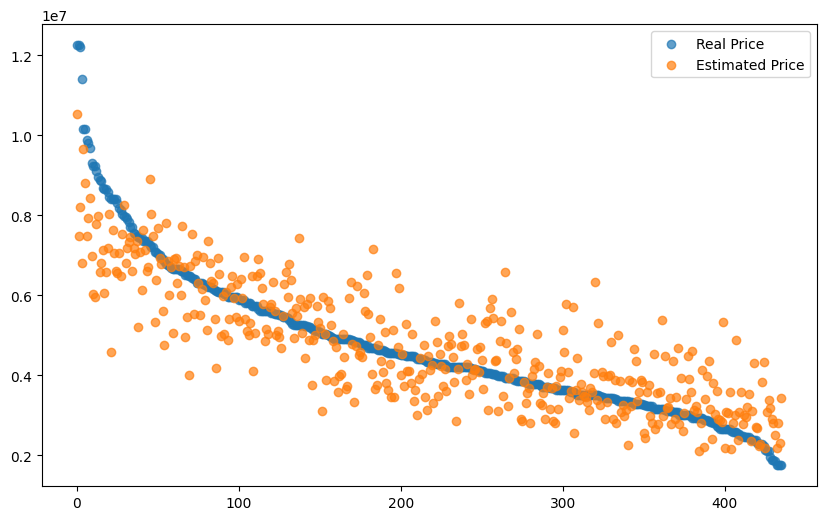

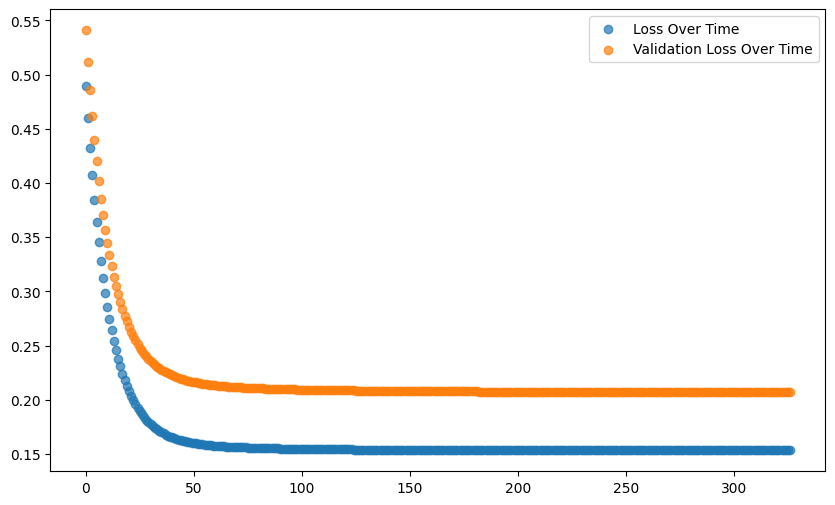

Iterations: 327
Parameters: 
251.986200x1 + 148611.517288x2 + 982454.166747x3 + 433095.058466x4 + 457619.793275x5 + 442495.437517x6 + 347801.535091x7 + 904137.086678x8 + 880116.230505x9 + 316656.077928x10 + 526984.202267x11 + -279478.125093
Cost: 535849473486.007324
Final Validation Cost: 2788386969975.533691


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import StandardScaler
def find(l, t):
  for i in range(len(l)):
    if l[i] == t:
      return i
  return -1
filepath = "/content/Housing.csv"

df = pd.read_csv(filepath)

chosenparams = ["area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "parking", "prefarea"]
scaler_X = StandardScaler() # Scaler for input features
scaler_y = StandardScaler() # Scaler for target variable

y = df.values[:, 0]
paramnames = df.columns.values[:]
params = np.zeros(len(chosenparams) + 1)
inputdata = []
for i in range(len(chosenparams)):
    column = find(paramnames, chosenparams[i])
    inputdata.append(df.values[:, column])


for i in range(len(inputdata)):
  for j in range(len(inputdata[i])):
    if inputdata[i][j] == "yes":
      inputdata[i][j] = 1
    elif inputdata[i][j] == "no":
      inputdata[i][j] = 0

inputdata = np.array(inputdata).T
originaldata = inputdata.copy()
originaldata = np.array(originaldata).T
inputdata = scaler_X.fit_transform(inputdata) # Fit and transform input features

validation_indices = np.arange(0, len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)

originaldata = originaldata.T
originaldata = np.delete(originaldata, validation_indices, axis=0)
originaldata = originaldata.T

inputdata = inputdata.T
validationdata = validationdata.T

index = np.arange(0, len(inputdata[0]))

y = scaler_y.fit_transform(y.reshape(-1, 1)).reshape(-1) # Fit and transform target variable

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

m = len(y)



cf = 10
lr = 0.02

def cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res))

def plot_result_to_target(result, y, x, loss, vloss):
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(y)), y, label='Real Price', alpha=0.7)
  plt.scatter(range(len(result)), result, label='Estimated Price', alpha=0.7)
  plt.legend() # Add this line to display labels
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(loss)), loss, label='Loss Over Time', alpha=0.7)
  plt.scatter(range(len(vloss)), vloss, label='Validation Loss Over Time', alpha=0.7)
  plt.legend() # Add this line to display labels
  #for i in range(len(x)):
    #plt.scatter(index, x[i], label=f'Index vs X{i+1}', alpha=0.7)
  plt.show()

def gradient(result, y, x):
  temp = np.zeros(len(params))
  for ind in range(len(params) - 1):
    temp[ind] = np.float64(np.sum((result - y) * x[ind])) / m
  temp[len(params) - 1] = np.float64(np.sum(result - y)) / m
  return temp

def linearfun(data, params):
  ans = np.zeros(len(data[0]))
  for i in range(len(params) - 1):
    ans += list(params[i] * data[i])
  return ans + params[len(params) - 1]

def printdata(iter, cf, params):
  print(f"Iterations: {iter}")
  print(f"Parameters: ")
  for i in range (len(params) - 1):
    print(f"{params[i]:.6f}x{i+1} +", end = " ")
  print(f"{params[len(params) - 1]:.6f}")
  print(f"Cost: {cf:.6f}")


def linregression(data, params, y, origdata):
  # Early setup
  grad = [500] * len(params)
  iteration = 0
  loss_over_time = []
  validation_loss_over_time = []

  # Core Iteration
  while any(abs(x) > 0.002 for x in grad):
    result = linearfun(data, params)
    cf = cost_function(result, y)
    grad = gradient(result, y, data)
    loss_over_time.append(cf)
    validation_cf = cost_function(linearfun(validationdata, params), validationy)
    validation_loss_over_time.append(validation_cf)
    for i in range(len(params)):
      params[i] = params[i] - lr * grad[i]
    if iteration % 100 == 0:
      printdata(iteration, cf, params)
    iteration += 1

  # Calculating final data
  original_y_values = scaler_y.inverse_transform(y.reshape(-1, 1)).reshape(-1)
  params[:-1] = (scaler_y.scale_ * params[:-1]) / scaler_X.scale_
  sum_term = np.sum((params[:-1] * scaler_X.mean_) / scaler_y.scale_)
  params[-1] = scaler_y.scale_ * params[-1] - scaler_y.scale_ * sum_term + scaler_y.mean_
  final_prediction = linearfun(origdata, params)
  #print(final_prediction)
  y = original_y_values
  cf = cost_function(final_prediction, y)
  validationcf = cost_function(linearfun(validationdata, params), validationy)

  # Plotting and displaying information
  plot_result_to_target(final_prediction, y, data, loss_over_time, validation_loss_over_time)
  printdata(iteration, cf, params)
  print(f"Final Validation Cost: {validationcf:.6f}")
  iteration = 0

linregression(inputdata, params, y, originaldata)

# Data Normalization

Iterations: 0
Parameters: 
0.000757x1 + 0.001120x2 + 0.000395x3 + 0.000888x4 + 0.000772x5 + 0.002602
Cost: 0.046663
Iterations: 100
Parameters: 
0.045287x1 + 0.062295x2 + 0.026163x3 + 0.053046x4 + 0.046471x5 + 0.138921
Cost: 0.011680
Iterations: 200
Parameters: 
0.062384x1 + 0.078884x2 + 0.039673x3 + 0.072692x4 + 0.064193x5 + 0.167202
Cost: 0.009098
Iterations: 300
Parameters: 
0.072385x1 + 0.084135x2 + 0.049746x3 + 0.083549x4 + 0.074286x5 + 0.168641
Cost: 0.008626
Iterations: 400
Parameters: 
0.080432x1 + 0.086446x2 + 0.058628x3 + 0.091655x4 + 0.081934x5 + 0.163698
Cost: 0.008326
Iterations: 500
Parameters: 
0.087829x1 + 0.087942x2 + 0.066908x3 + 0.098576x4 + 0.088485x5 + 0.157508
Cost: 0.008071
Iterations: 600
Parameters: 
0.094912x1 + 0.089165x2 + 0.074753x3 + 0.104749x4 + 0.094320x5 + 0.151340
Cost: 0.007848
Iterations: 700
Parameters: 
0.101773x1 + 0.090255x2 + 0.082223x3 + 0.110321x4 + 0.099570x5 + 0.145488
Cost: 0.007650
Iterations: 800
Parameters: 
0.108441x1 + 0.091253x2 + 0.0

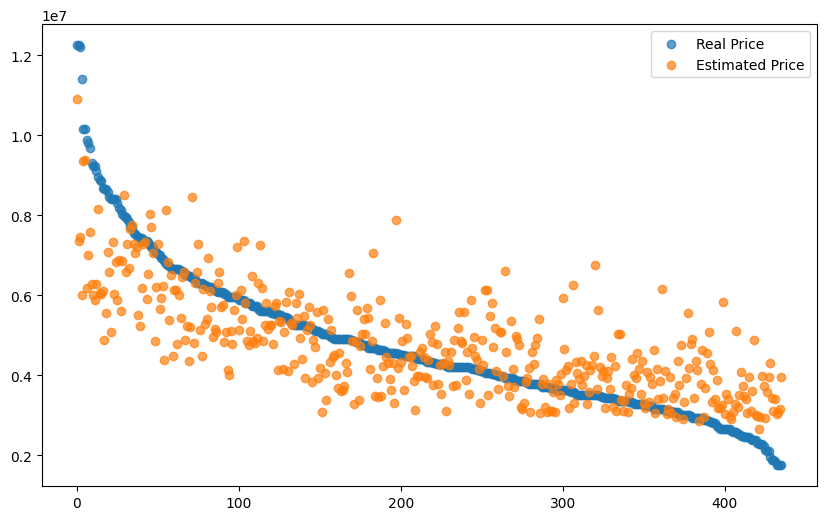

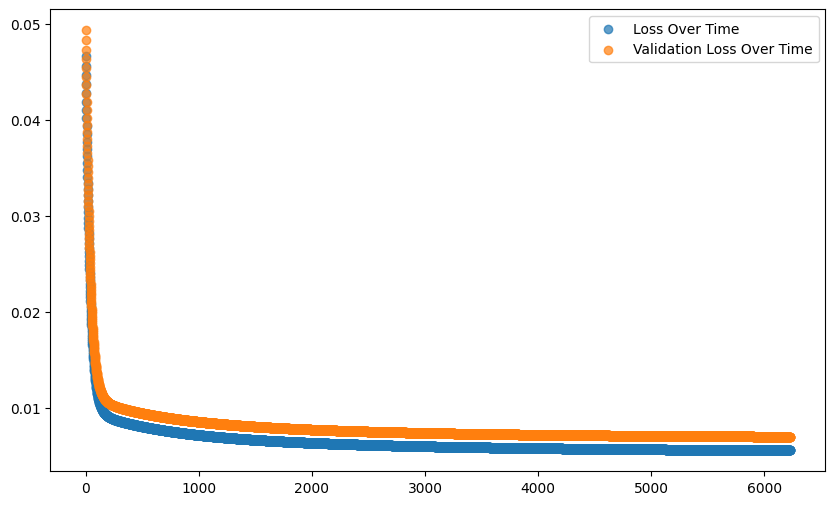

Iterations: 6231
Parameters: 
246.698549x1 + 227476.203240x2 + 963154.660742x3 + 573861.153797x4 + 473624.060876x5 + 208554.298459
Cost: 746641910896.747192
Final Validation Cost: 935606197258.459839


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import StandardScaler
def find(l, t):
  for i in range(len(l)):
    if l[i] == t:
      return i
  return -1
def standardize2d(data, matrix):
  for i in range(len(data)):
    min = np.min(data[i])
    max = np.max(data[i])
    for j in range(len(data[i])):
      data[i][j] = (data[i][j] - min) / (max - min)
    matrix.append([min, (max-min)])
def standardize1d(data, matrix):
  min = np.min(data)
  max = np.max(data)
  for j in range(len(data)):
    data[j] = (data[j] - min) / (max - min)
  matrix.append([min, (max-min)])
def destandardize2d(data, matrix):
  for i in range(len(data)):
    for j in range(len(data[i])):
      data[i][j] = (data[i][j] * matrix[i][1]) + matrix[i][0]
def destandardize1d(data, matrix):
  for i in range(len(data)):
    data[i] = (data[i] * matrix[0][1]) + matrix[0][0]
def destandardize_i(y, x, inter, params):
  sum = 0
  for i in range(len(params) - 1):
    sum += params[i] * x[i][0]
  return y[0][0] + (inter * y[0][1]) - sum

filepath = "/content/Housing.csv"

df = pd.read_csv(filepath)

chosenparams = ["area", "bedrooms", "bathrooms", "stories", "parking"]

standardization_matrix = []
ystandard = []

y = df.values[:, 0]
paramnames = df.columns.values[:]
params = np.zeros(len(chosenparams) + 1)
inputdata = []
for i in range(len(chosenparams)):
    column = find(paramnames, chosenparams[i])
    if df.values[1, column] == "yes" or df.values[1, column] == "no":
      inputdata.append(df.values[:, column].astype(int))
    else:
      for j in range(len(df.values[:, column])):
        df.values[:, column][j] = np.float64(df.values[:, column][j])
      inputdata.append(df.values[:, column])

inputdata = np.array(inputdata)
standardize2d(inputdata, standardization_matrix)

standardize1d(y, ystandard)

inputdata = inputdata.T
validation_indices = np.arange(0, len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)
inputdata = inputdata.T
validationdata = validationdata.T

index = np.arange(0, len(inputdata[0]))

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

m = len(y)



cf = 10
lr = 0.01

def cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res))

def plot_result_to_target(result, y, x, loss, vloss):
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(y)), y, label='Real Price', alpha=0.7)
  plt.scatter(range(len(result)), result, label='Estimated Price', alpha=0.7)
  plt.legend() # Add this line to display labels
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(loss)), loss, label='Loss Over Time', alpha=0.7)
  plt.scatter(range(len(vloss)), vloss, label='Validation Loss Over Time', alpha=0.7)
  plt.legend() # Add this line to display labels
  #for i in range(len(x)):
    #plt.scatter(index, x[i], label=f'Index vs X{i+1}', alpha=0.7)
  plt.show()

def gradient(result, y, x):
  temp = np.zeros(len(params))
  for ind in range(len(params) - 1):
    temp[ind] = np.float64(np.sum((result - y) * x[ind])) / m
  temp[len(params) - 1] = np.float64(np.sum(result - y)) / m
  return temp

def linearfun(data, params):
  ans = np.zeros(len(data[0]))
  for i in range(len(params) - 1):
    ans += list(params[i] * data[i])
  return ans + params[len(params) - 1]

def printdata(iter, cf, params):
  print(f"Iterations: {iter}")
  print(f"Parameters: ")
  for i in range (len(params) - 1):
    print(f"{params[i]:.6f}x{i+1} +", end = " ")
  print(f"{params[len(params) - 1]:.6f}")
  print(f"Cost: {cf:.6f}")


def linregression(data, params, y):
  # Early setup
  grad = [500] * len(params)
  iteration = 0
  loss_over_time = []
  validation_loss_over_time = []

  # Core Iteration
  while any(abs(x) > 0.002 for x in grad):
    result = linearfun(data, params)
    cf = cost_function(result, y)
    grad = gradient(result, y, data)
    loss_over_time.append(cf)
    validation_cf = cost_function(linearfun(validationdata, params), validationy)
    validation_loss_over_time.append(validation_cf)
    for i in range(len(params)):
      params[i] = params[i] - lr * grad[i]
    if iteration % 100 == 0:
      printdata(iteration, cf, params)
    iteration += 1

  # Final Calculations
  destandardize1d(y, ystandard)
  destandardize1d(validationy, ystandard) # Destandardize validation target
  destandardize2d(validationdata, standardization_matrix)
  destandardize2d(data, standardization_matrix)

  for i in range(len(params) - 1):
    params[i] = params[i] * (ystandard[0][1] / standardization_matrix[i][1])

  params[len(params) - 1] = destandardize_i(ystandard, standardization_matrix, params[len(params) - 1], params)


  final_prediction = linearfun(data, params)
  #print(final_prediction)
  cf = cost_function(final_prediction, y)
  validationcf = cost_function(linearfun(validationdata, params), validationy)

  # Plotting and displaying information
  plot_result_to_target(final_prediction, y, data, loss_over_time, validation_loss_over_time)
  printdata(iteration, cf, params)
  print(f"Final Validation Cost: {validationcf:.6f}")
  iteration = 0



linregression(inputdata, params, y)

Iterations: 0
Parameters: 
0.000757x1 + 0.001120x2 + 0.000395x3 + 0.000888x4 + 0.002382x5 + 0.000663x6 + 0.001063x7 + 0.000136x8 + 0.001132x9 + 0.000772x10 + 0.000847x11 + 0.002602
Cost: 0.046663
Iterations: 100
Parameters: 
0.031880x1 + 0.042569x2 + 0.020537x3 + 0.039153x4 + 0.083890x5 + 0.027370x6 + 0.037211x7 + 0.006947x8 + 0.049804x9 + 0.033714x10 + 0.034102x11 + 0.090122
Cost: 0.007670
Iterations: 200
Parameters: 
0.039918x1 + 0.047670x2 + 0.030297x3 + 0.050531x4 + 0.085481x5 + 0.033085x6 + 0.037705x7 + 0.010251x8 + 0.063170x9 + 0.043381x10 + 0.040258x11 + 0.089731
Cost: 0.006912
Iterations: 300
Parameters: 
0.045952x1 + 0.049830x2 + 0.038732x3 + 0.058783x4 + 0.081453x5 + 0.036491x6 + 0.035821x7 + 0.013254x8 + 0.071545x9 + 0.050579x10 + 0.043619x11 + 0.083302
Cost: 0.006514
Iterations: 400
Parameters: 
0.051657x1 + 0.051683x2 + 0.046610x3 + 0.065925x4 + 0.077556x5 + 0.039181x6 + 0.034113x7 + 0.016186x8 + 0.077776x9 + 0.057007x10 + 0.046222x11 + 0.077157
Cost: 0.006206
Iterations: 

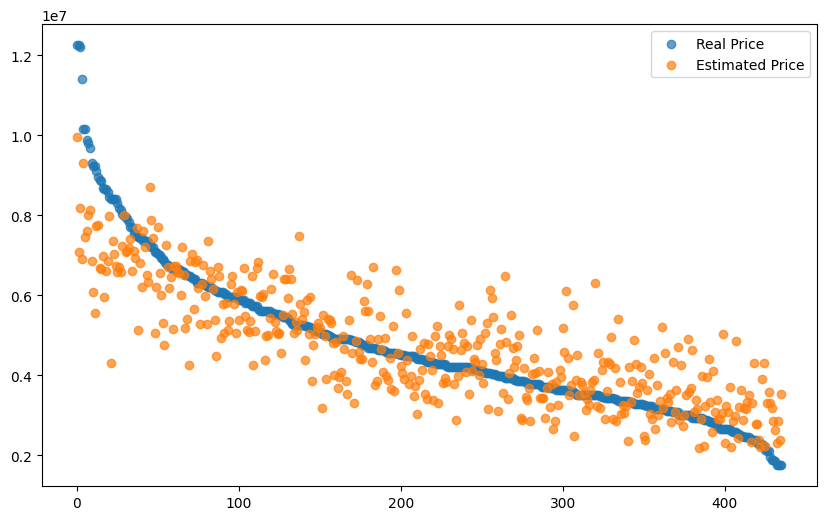

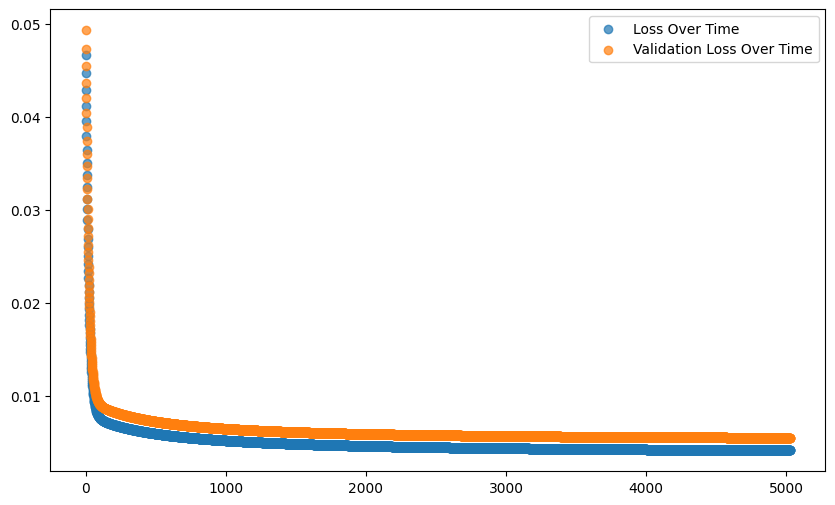

Iterations: 5029
Parameters: 
164.094103x1 + 179330.405203x2 + 774057.084434x3 + 467109.562765x4 + 518887.880394x5 + 510187.236558x6 + 346154.177011x7 + 838481.275627x8 + 920569.401074x9 + 411343.226393x10 + 603239.575908x11 + 137763.283572
Cost: 0.004177
Final Validation Cost: 736938747676.077881


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import StandardScaler
def find(l, t):
  for i in range(len(l)):
    if l[i] == t:
      return i
  return -1
def standardize2d(data, matrix):
  for i in range(len(data)):
    min = np.min(data[i])
    max = np.max(data[i])
    for j in range(len(data[i])):
      data[i][j] = (data[i][j] - min) / (max - min)
    matrix.append([min, (max-min)])
def standardize1d(data, matrix):
  min = np.min(data)
  max = np.max(data)
  for j in range(len(data)):
    data[j] = (data[j] - min) / (max - min)
  matrix.append([min, (max-min)])
def destandardize2d(data, matrix):
  for i in range(len(data)):
    for j in range(len(data[i])):
      data[i][j] = (data[i][j] * matrix[i][1]) + matrix[i][0]
def destandardize1d(data, matrix):
  for i in range(len(data)):
    data[i] = (data[i] * matrix[0][1]) + matrix[0][0]
def destandardize_i(y, x, inter, params):
  sum = 0
  for i in range(len(params) - 1):
    sum += params[i] * x[i][0]
  return y[0][0] + (inter * y[0][1]) - sum

filepath = "/content/Housing.csv"

df = pd.read_csv(filepath)

chosenparams = ["area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "parking", "prefarea"]

standardization_matrix = []
ystandard = []

y = df.values[:, 0]
paramnames = df.columns.values[:]
params = np.zeros(len(chosenparams) + 1)
inputdata = []
for i in range(len(chosenparams)):
    column = find(paramnames, chosenparams[i])
    inputdata.append(df.values[:, column])

for i in range(len(inputdata)):
  for j in range(len(inputdata[i])):
    if inputdata[i][j] == "yes":
      inputdata[i][j] = 1
    elif inputdata[i][j] == "no":
      inputdata[i][j] = 0

inputdata = np.array(inputdata)
standardize2d(inputdata, standardization_matrix)

standardize1d(y, ystandard)

inputdata = inputdata.T
validation_indices = np.arange(0, len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)
inputdata = inputdata.T
validationdata = validationdata.T

index = np.arange(0, len(inputdata[0]))

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

m = len(y)



cf = 10
lr = 0.01

def cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res))

def plot_result_to_target(result, y, x, loss, vloss):
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(y)), y, label='Real Price', alpha=0.7)
  plt.scatter(range(len(result)), result, label='Estimated Price', alpha=0.7)
  plt.legend() # Add this line to display labels
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(loss)), loss, label='Loss Over Time', alpha=0.7)
  plt.scatter(range(len(vloss)), vloss, label='Validation Loss Over Time', alpha=0.7)
  plt.legend() # Add this line to display labels
  #for i in range(len(x)):
    #plt.scatter(index, x[i], label=f'Index vs X{i+1}', alpha=0.7)
  plt.show()

def gradient(result, y, x):
  temp = np.zeros(len(params))
  for ind in range(len(params) - 1):
    temp[ind] = np.float64(np.sum((result - y) * x[ind])) / m
  temp[len(params) - 1] = np.float64(np.sum(result - y)) / m
  return temp

def linearfun(data, params):
  ans = np.zeros(len(data[0]))
  for i in range(len(params) - 1):
    ans += list(params[i] * data[i])
  return ans + params[len(params) - 1]

def printdata(iter, cf, params):
  print(f"Iterations: {iter}")
  print(f"Parameters: ")
  for i in range (len(params) - 1):
    print(f"{params[i]:.6f}x{i+1} +", end = " ")
  print(f"{params[len(params) - 1]:.6f}")
  print(f"Cost: {cf:.6f}")


def linregression(data, params, y):
  # Early setup
  grad = [500] * len(params)
  iteration = 0
  loss_over_time = []
  validation_loss_over_time = []

  # Core Iteration
  while any(abs(x) > 0.002 for x in grad):
    result = linearfun(data, params)
    cf = cost_function(result, y)
    grad = gradient(result, y, data)
    loss_over_time.append(cf)
    validation_cf = cost_function(linearfun(validationdata, params), validationy)
    validation_loss_over_time.append(validation_cf)
    for i in range(len(params)):
      params[i] = params[i] - lr * grad[i]
    if iteration % 100 == 0:
      printdata(iteration, cf, params)
    iteration += 1

  # Final Calculations
  destandardize1d(y, ystandard)
  destandardize1d(validationy, ystandard) # Destandardize validation target
  destandardize2d(validationdata, standardization_matrix)
  destandardize2d(data, standardization_matrix)

  for i in range(len(params) - 1):
    params[i] = params[i] * (ystandard[0][1] / standardization_matrix[i][1])

  params[len(params) - 1] = destandardize_i(ystandard, standardization_matrix, params[len(params) - 1], params)


  final_prediction = linearfun(data, params)
  #print(final_prediction)
  validationcf = cost_function(linearfun(validationdata, params), validationy)

  # Plotting and displaying information
  plot_result_to_target(final_prediction, y, data, loss_over_time, validation_loss_over_time)
  printdata(iteration, cf, params)
  print(f"Final Validation Cost: {validationcf:.6f}")
  iteration = 0



linregression(inputdata, params, y)

# Data Normalization + Parameters Penalty

The combined cost of the Standardization algorithms was around 3.9 trillion, versus 1.6 trillion for the Normalization algorithms. Therefore, I will be using Normalization for this step

Iterations: 0
Parameters: 
0.000757x1 + 0.001120x2 + 0.000395x3 + 0.000888x4 + 0.000772x5 + 0.002602
Cost: 0.046663
Iterations: 100
Parameters: 
0.045287x1 + 0.062295x2 + 0.026163x3 + 0.053046x4 + 0.046471x5 + 0.138921
Cost: 0.011691
Iterations: 200
Parameters: 
0.062384x1 + 0.078884x2 + 0.039673x3 + 0.072691x4 + 0.064192x5 + 0.167202
Cost: 0.009119
Iterations: 300
Parameters: 
0.072385x1 + 0.084134x2 + 0.049745x3 + 0.083549x4 + 0.074286x5 + 0.168641
Cost: 0.008653
Iterations: 400
Parameters: 
0.080432x1 + 0.086445x2 + 0.058628x3 + 0.091654x4 + 0.081933x5 + 0.163698
Cost: 0.008359
Iterations: 500
Parameters: 
0.087828x1 + 0.087942x2 + 0.066908x3 + 0.098575x4 + 0.088485x5 + 0.157509
Cost: 0.008109
Iterations: 600
Parameters: 
0.094912x1 + 0.089164x2 + 0.074752x3 + 0.104748x4 + 0.094319x5 + 0.151340
Cost: 0.007890
Iterations: 700
Parameters: 
0.101773x1 + 0.090254x2 + 0.082222x3 + 0.110320x4 + 0.099569x5 + 0.145489
Cost: 0.007698
Iterations: 800
Parameters: 
0.108440x1 + 0.091253x2 + 0.0

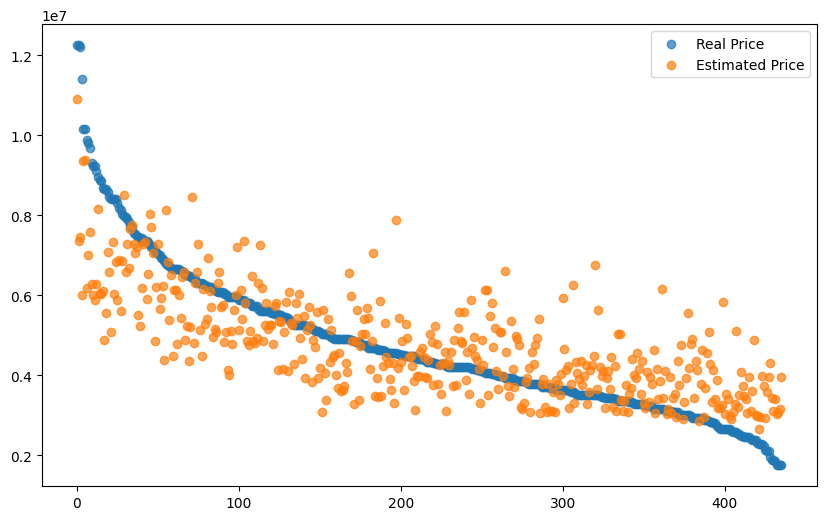

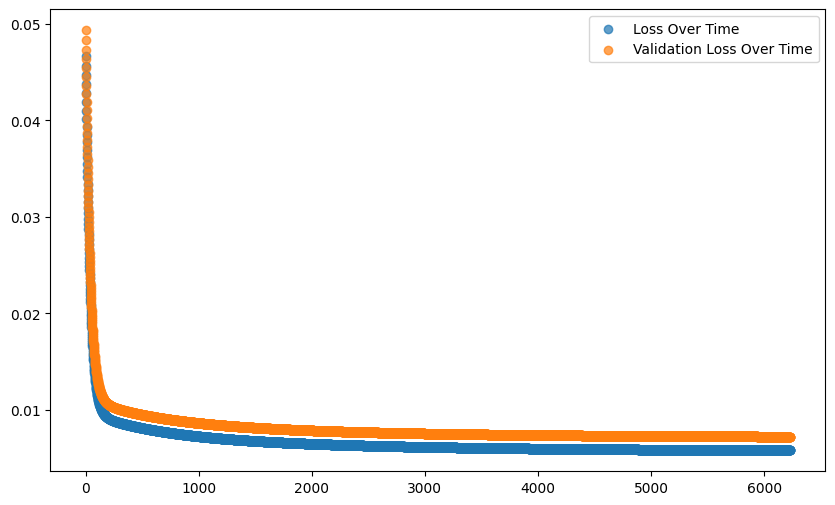

Iterations: 6232
Parameters: 
246.702085x1 + 227467.401176x2 + 963158.469326x3 + 573846.737300x4 + 473604.787173x5 + 208594.558944
Cost: 0.005803
Final Validation Cost: 935605284008.548706


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import StandardScaler
def find(l, t):
  for i in range(len(l)):
    if l[i] == t:
      return i
  return -1
def standardize2d(data, matrix):
  for i in range(len(data)):
    min = np.min(data[i])
    max = np.max(data[i])
    for j in range(len(data[i])):
      data[i][j] = (data[i][j] - min) / (max - min)
    matrix.append([min, (max-min)])
def standardize1d(data, matrix):
  min = np.min(data)
  max = np.max(data)
  for j in range(len(data)):
    data[j] = (data[j] - min) / (max - min)
  matrix.append([min, (max-min)])
def destandardize2d(data, matrix):
  for i in range(len(data)):
    for j in range(len(data[i])):
      data[i][j] = (data[i][j] * matrix[i][1]) + matrix[i][0]
def destandardize1d(data, matrix):
  for i in range(len(data)):
    data[i] = (data[i] * matrix[0][1]) + matrix[0][0]
def destandardize_i(y, x, inter, params):
  sum = 0
  for i in range(len(params) - 1):
    sum += params[i] * x[i][0]
  return y[0][0] + (inter * y[0][1]) - sum

filepath = "/content/Housing.csv"

df = pd.read_csv(filepath)

chosenparams = ["area", "bedrooms", "bathrooms", "stories", "parking"]

standardization_matrix = []
ystandard = []

y = df.values[:, 0]
paramnames = df.columns.values[:]
params = np.zeros(len(chosenparams) + 1)
inputdata = []
for i in range(len(chosenparams)):
    column = find(paramnames, chosenparams[i])
    if df.values[1, column] == "yes" or df.values[1, column] == "no":
      inputdata.append(df.values[:, column].astype(int))
    else:
      for j in range(len(df.values[:, column])):
        df.values[:, column][j] = np.float64(df.values[:, column][j])
      inputdata.append(df.values[:, column])

inputdata = np.array(inputdata)
standardize2d(inputdata, standardization_matrix)

standardize1d(y, ystandard)

inputdata = inputdata.T
validation_indices = np.arange(0, len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)
inputdata = inputdata.T
validationdata = validationdata.T

index = np.arange(0, len(inputdata[0]))

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

m = len(y)

cf = 10
lr = 0.01
rp = 0.001
ii = len(params) - 1

def cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res)) + rp * np.sum(params[:ii] ** 2)
def validation_cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res))
def plot_result_to_target(result, y, x, loss, vloss):
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(y)), y, label='Real Price', alpha=0.7)
  plt.scatter(range(len(result)), result, label='Estimated Price', alpha=0.7)
  plt.legend() # Add this line to display labels
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(loss)), loss, label='Loss Over Time', alpha=0.7)
  plt.scatter(range(len(vloss)), vloss, label='Validation Loss Over Time', alpha=0.7)
  plt.legend() # Add this line to display labels
  #for i in range(len(x)):
    #plt.scatter(index, x[i], label=f'Index vs X{i+1}', alpha=0.7)
  plt.show()

def gradient(result, y, x):
  temp = np.zeros(len(params))
  for ind in range(ii):
    temp[ind] = np.float64(np.sum((result - y) * x[ind])) / m
  temp[ii] = np.float64(np.sum(result - y)) / m
  return temp

def linearfun(data, params):
  ans = np.zeros(len(data[0]))
  for i in range(ii):
    ans += list(params[i] * data[i])
  return ans + params[ii]

def printdata(iter, cf, params):
  print(f"Iterations: {iter}")
  print(f"Parameters: ")
  for i in range (ii):
    print(f"{params[i]:.6f}x{i+1} +", end = " ")
  print(f"{params[ii]:.6f}")
  print(f"Cost: {cf:.6f}")


def linregression(data, params, y):
  # Early setup
  grad = [500] * len(params)
  iteration = 0
  loss_over_time = []
  validation_loss_over_time = []

  # Core Iteration
  while any(abs(x) > 0.002 for x in grad):
    result = linearfun(data, params)
    cf = cost_function(result, y)
    grad = gradient(result, y, data)
    loss_over_time.append(cf)
    validation_cf = cost_function(linearfun(validationdata, params), validationy)
    validation_loss_over_time.append(validation_cf)
    for i in range(ii):
      params[i] = params[i] - lr * (grad[i] + (rp * params[i] / m ))
    params[ii] = params[ii] - lr * grad[ii]
    if iteration % 100 == 0:
      printdata(iteration, cf, params)
    iteration += 1

  # Final Calculations
  destandardize1d(y, ystandard)
  destandardize1d(validationy, ystandard) # Destandardize validation target
  destandardize2d(validationdata, standardization_matrix)
  destandardize2d(data, standardization_matrix)

  for i in range(ii):
    params[i] = params[i] * (ystandard[0][1] / standardization_matrix[i][1])

  params[ii] = destandardize_i(ystandard, standardization_matrix, params[ii], params)


  final_prediction = linearfun(data, params)
  #print(final_prediction)
  validationcf = validation_cost_function(linearfun(validationdata, params), validationy)

  # Plotting and displaying information
  plot_result_to_target(final_prediction, y, data, loss_over_time, validation_loss_over_time)
  printdata(iteration, cf, params)
  print(f"Final Validation Cost: {validationcf:.6f}")
  iteration = 0



linregression(inputdata, params, y)

Iterations: 0
Parameters: 
0.000757x1 + 0.001120x2 + 0.000395x3 + 0.000888x4 + 0.002382x5 + 0.000663x6 + 0.001063x7 + 0.000136x8 + 0.001132x9 + 0.000772x10 + 0.000847x11 + 0.002602
Cost: 0.046663
Iterations: 100
Parameters: 
0.031879x1 + 0.042568x2 + 0.020537x3 + 0.039152x4 + 0.083888x5 + 0.027370x6 + 0.037209x7 + 0.006947x8 + 0.049802x9 + 0.033713x10 + 0.034101x11 + 0.090124
Cost: 0.008231
Iterations: 200
Parameters: 
0.039916x1 + 0.047667x2 + 0.030295x3 + 0.050528x4 + 0.085477x5 + 0.033083x6 + 0.037703x7 + 0.010250x8 + 0.063166x9 + 0.043378x10 + 0.040256x11 + 0.089736
Cost: 0.007653
Iterations: 300
Parameters: 
0.045948x1 + 0.049826x2 + 0.038729x3 + 0.058778x4 + 0.081447x5 + 0.036489x6 + 0.035819x7 + 0.013253x8 + 0.071540x9 + 0.050575x10 + 0.043616x11 + 0.083312
Cost: 0.007370
Iterations: 400
Parameters: 
0.051651x1 + 0.051677x2 + 0.046604x3 + 0.065918x4 + 0.077549x5 + 0.039178x6 + 0.034110x7 + 0.016183x8 + 0.077769x9 + 0.057000x10 + 0.046218x11 + 0.077171
Cost: 0.007173
Iterations: 

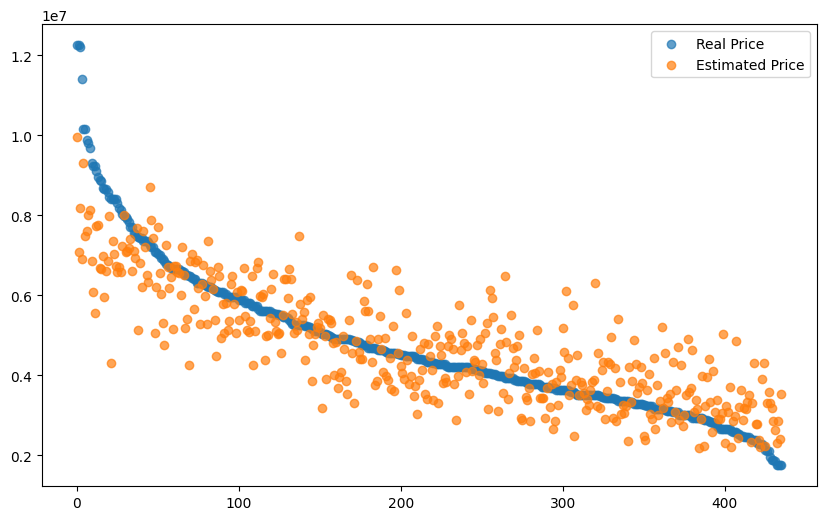

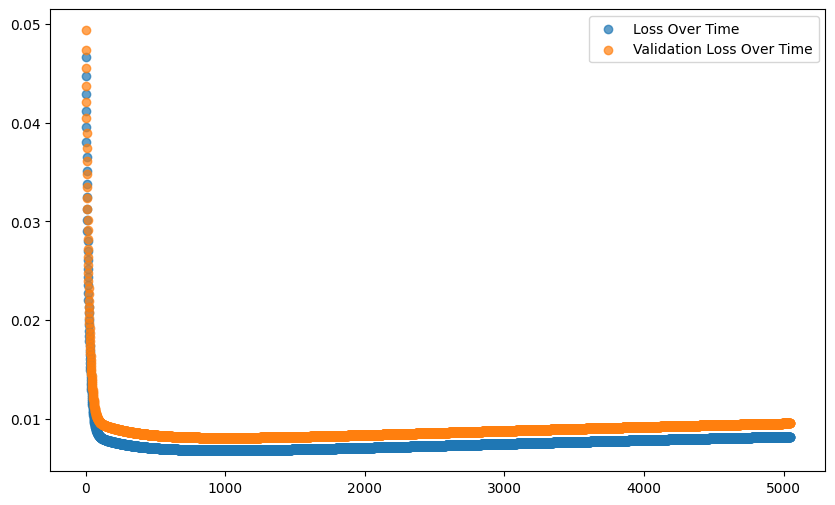

Iterations: 5049
Parameters: 
164.205241x1 + 179220.246644x2 + 774273.458941x3 + 466814.531779x4 + 518976.889377x5 + 509920.480394x6 + 346165.595653x7 + 838322.027916x8 + 920458.624210x9 + 410936.878427x10 + 603006.420653x11 + 138070.673222
Cost: 0.008213
Final Validation Cost: 736899445026.186401


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import StandardScaler
def find(l, t):
  for i in range(len(l)):
    if l[i] == t:
      return i
  return -1
def standardize2d(data, matrix):
  for i in range(len(data)):
    min = np.min(data[i])
    max = np.max(data[i])
    for j in range(len(data[i])):
      data[i][j] = (data[i][j] - min) / (max - min)
    matrix.append([min, (max-min)])
def standardize1d(data, matrix):
  min = np.min(data)
  max = np.max(data)
  for j in range(len(data)):
    data[j] = (data[j] - min) / (max - min)
  matrix.append([min, (max-min)])
def destandardize2d(data, matrix):
  for i in range(len(data)):
    for j in range(len(data[i])):
      data[i][j] = (data[i][j] * matrix[i][1]) + matrix[i][0]
def destandardize1d(data, matrix):
  for i in range(len(data)):
    data[i] = (data[i] * matrix[0][1]) + matrix[0][0]
def destandardize_i(y, x, inter, params):
  sum = 0
  for i in range(len(params) - 1):
    sum += params[i] * x[i][0]
  return y[0][0] + (inter * y[0][1]) - sum

filepath = "/content/Housing.csv"

df = pd.read_csv(filepath)

chosenparams = ["area", "bedrooms", "bathrooms", "stories", "mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "parking", "prefarea"]

standardization_matrix = []
ystandard = []

y = df.values[:, 0]
paramnames = df.columns.values[:]
params = np.zeros(len(chosenparams) + 1)
inputdata = []
for i in range(len(chosenparams)):
    column = find(paramnames, chosenparams[i])
    inputdata.append(df.values[:, column])


for i in range(len(inputdata)):
  for j in range(len(inputdata[i])):
    if inputdata[i][j] == "yes":
      inputdata[i][j] = 1
    elif inputdata[i][j] == "no":
      inputdata[i][j] = 0

inputdata = np.array(inputdata)
standardize2d(inputdata, standardization_matrix)

standardize1d(y, ystandard)

inputdata = inputdata.T
validation_indices = np.arange(0, len(inputdata), 5)
validationdata = inputdata[validation_indices]
inputdata = np.delete(inputdata, validation_indices, axis=0)
inputdata = inputdata.T
validationdata = validationdata.T

index = np.arange(0, len(inputdata[0]))

validationy = y[validation_indices]
y = np.delete(y, validation_indices)

m = len(y)

cf = 10
lr = 0.01
rp = 0.03
ii = len(params) - 1

def cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res)) + rp * np.sum(params[:ii] ** 2)
def validation_cost_function(res, y):
  for i in range(len(res)):
    res[i] = np.float64(res[i])
  for i in range(len(y)):
    y[i] = np.float64(y[i])
  return np.sum((res - y) ** 2) / (2 * len(res))

def plot_result_to_target(result, y, x, loss, vloss):
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(y)), y, label='Real Price', alpha=0.7)
  plt.scatter(range(len(result)), result, label='Estimated Price', alpha=0.7)
  plt.legend() # Add this line to display labels
  plt.figure(figsize=(10, 6))
  plt.scatter(range(len(loss)), loss, label='Loss Over Time', alpha=0.7)
  plt.scatter(range(len(vloss)), vloss, label='Validation Loss Over Time', alpha=0.7)
  plt.legend() # Add this line to display labels
  #for i in range(len(x)):
    #plt.scatter(index, x[i], label=f'Index vs X{i+1}', alpha=0.7)
  plt.show()

def gradient(result, y, x):
  temp = np.zeros(len(params))
  for ind in range(ii):
    temp[ind] = np.float64(np.sum((result - y) * x[ind])) / m
  temp[ii] = np.float64(np.sum(result - y)) / m
  return temp

def linearfun(data, params):
  ans = np.zeros(len(data[0]))
  for i in range(ii):
    ans += list(params[i] * data[i])
  return ans + params[ii]

def printdata(iter, cf, params):
  print(f"Iterations: {iter}")
  print(f"Parameters: ")
  for i in range (ii):
    print(f"{params[i]:.6f}x{i+1} +", end = " ")
  print(f"{params[ii]:.6f}")
  print(f"Cost: {cf:.6f}")


def linregression(data, params, y):
  # Early setup
  grad = [500] * len(params)
  iteration = 0
  loss_over_time = []
  validation_loss_over_time = []

  # Core Iteration
  while any(abs(x) > 0.002 for x in grad):
    result = linearfun(data, params)
    cf = cost_function(result, y)
    grad = gradient(result, y, data)
    loss_over_time.append(cf)
    validation_cf = cost_function(linearfun(validationdata, params), validationy)
    validation_loss_over_time.append(validation_cf)
    for i in range(ii):
      params[i] = params[i] - lr * (grad[i] + (rp * params[i] / m ))
    params[ii] = params[ii] - lr * grad[ii]
    if iteration % 100 == 0:
      printdata(iteration, cf, params)
    iteration += 1

  # Final Calculations
  destandardize1d(y, ystandard)
  destandardize1d(validationy, ystandard) # Destandardize validation target
  destandardize2d(validationdata, standardization_matrix)
  destandardize2d(data, standardization_matrix)

  for i in range(ii):
    params[i] = params[i] * (ystandard[0][1] / standardization_matrix[i][1])

  params[ii] = destandardize_i(ystandard, standardization_matrix, params[ii], params)


  final_prediction = linearfun(data, params)
  #print(final_prediction)
  validationcf = validation_cost_function(linearfun(validationdata, params), validationy)

  # Plotting and displaying information
  plot_result_to_target(final_prediction, y, data, loss_over_time, validation_loss_over_time)
  printdata(iteration, cf, params)
  print(f"Final Validation Cost: {validationcf:.6f}")
  iteration = 0



linregression(inputdata, params, y)